In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/notebooks'
os.chdir(project_path)

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df['Balance_Per_Product'] = df['Balance'] / df['NumOfProducts']
df['Tenure_Age_Ratio'] = df['Tenure'] / df['Age']
df['Is_Senior'] = (df['Age'] >= 60).astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CreditScore          10000 non-null  int64  
 1   Geography            10000 non-null  object 
 2   Gender               10000 non-null  object 
 3   Age                  10000 non-null  int64  
 4   Tenure               10000 non-null  int64  
 5   Balance              10000 non-null  float64
 6   NumOfProducts        10000 non-null  int64  
 7   HasCrCard            10000 non-null  int64  
 8   IsActiveMember       10000 non-null  int64  
 9   EstimatedSalary      10000 non-null  float64
 10  Exited               10000 non-null  int64  
 11  Balance_Per_Product  10000 non-null  float64
 12  Tenure_Age_Ratio     10000 non-null  float64
 13  Is_Senior            10000 non-null  int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 1.1+ MB


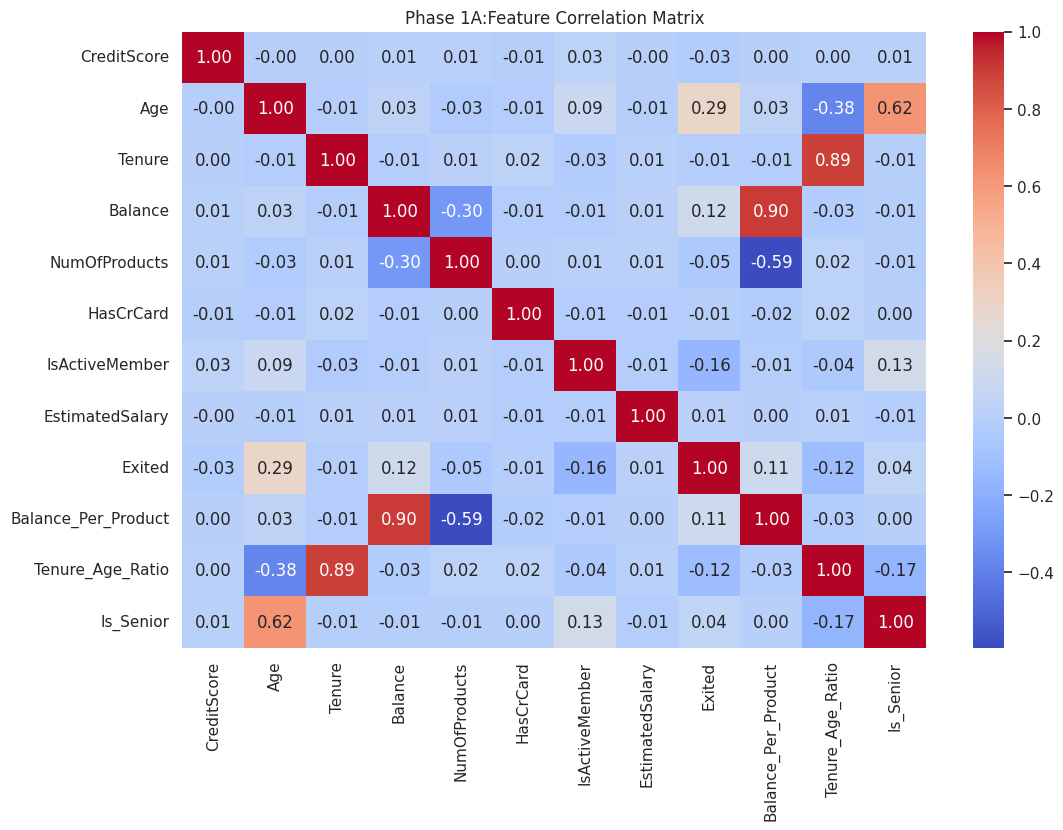

In [4]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Phase 1A:Feature Correlation Matrix")
plt.savefig('../results/figures/01_Data_Engineering_Phase1A_FeatureCorrelationMatrix.png', dpi=300)
plt.show()

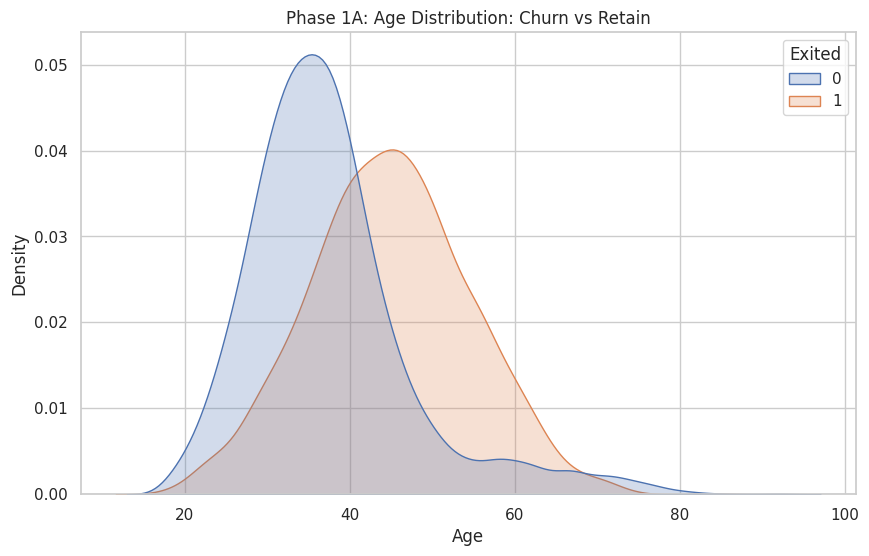

In [5]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, common_norm=False)
plt.title("Phase 1A: Age Distribution: Churn vs Retain")
plt.savefig('../results/figures/01_Data_Engineering_Phase1A_AgeDistribution_ChurnVSRetain.png', dpi=300)
plt.show()

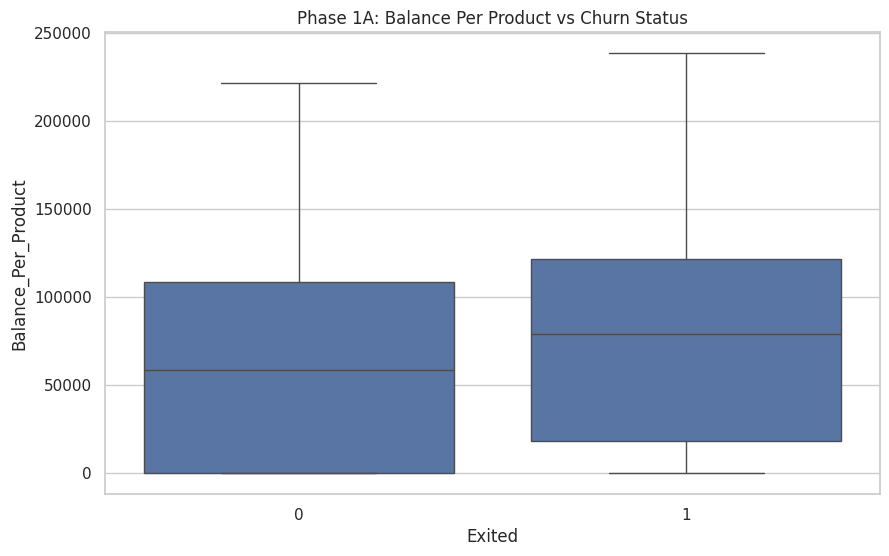

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='Balance_Per_Product', data=df)
plt.title("Phase 1A: Balance Per Product vs Churn Status")
plt.savefig('../results/figures/01_Data_Engineering_Phase1A_BalancePerProductVsChurnStatus.png', dpi=300)
plt.show()

In [7]:
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print(f"Total Columns after encoding: {df_encoded.shape[1]}")
df_encoded.head()

Total Columns after encoding: 15


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Per_Product,Tenure_Age_Ratio,Is_Senior,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,0,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,83807.860000,0.024390,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,53220.266667,0.190476,0,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,125510.820000,0.046512,0,False,True,False


In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (8000, 14)
Test Shape: (2000, 14)


In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original Train Balance: {Counter(y_train)}")
print(f"SMOTE Train Balance:    {Counter(y_train_res)}")

Original Train Balance: Counter({0: 6370, 1: 1630})
SMOTE Train Balance:    Counter({1: 6370, 0: 6370})


In [10]:
os.makedirs('../data/processed/', exist_ok=True)

train_df = pd.concat([X_train_res, y_train_res], axis=1)
train_df.to_csv('../data/processed/train_augmented.csv', index=False)

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('../data/processed/test_original.csv', index=False)

print("Files saved: 'train_augmented.csv' and 'test_original.csv'")

Files saved: 'train_augmented.csv' and 'test_original.csv'
